In [1]:
from pathlib import Path
from urllib.request import urlretrieve

# Windows-safe bootstrap; the upstream panns_inference module expects this file during import.
panns_labels_dir = Path.home() / "panns_data"
panns_labels_dir.mkdir(parents=True, exist_ok=True)
panns_labels_file = panns_labels_dir / "class_labels_indices.csv"
if not panns_labels_file.exists():
    urlretrieve(
        "https://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/class_labels_indices.csv",
        panns_labels_file,
    )

In [2]:
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from thop import profile
except ImportError as exc:
    raise ImportError("Install THOP first: %pip install thop") from exc

from panns_inference import AudioTagging

In [3]:
AUDIO_DIR = Path(".")
MODELS_DIR = AUDIO_DIR / "models"
RESULTS_DIR = AUDIO_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PRETRAINED_PATH = MODELS_DIR / "pretrained" / "Cnn14_mAP=0.431.pth"
BASELINE_HEAD_PATH = MODELS_DIR / "panns_cnn14_binary_head_2p0s.pt"
EXIT1_HEAD_PATH = MODELS_DIR / "panns_exit1_block2_2p0s.pt"
EXIT2_HEAD_PATH = MODELS_DIR / "panns_exit2_block4_2p0s.pt"
POLICIES_PATH = RESULTS_DIR / "panns_early_exit_policy_results_2p0s.csv"
STANDALONE_PATH = RESULTS_DIR / "panns_early_exit_standalone_2p0s.csv"

CONTEXT_SECONDS = 2.0
SAMPLE_RATE = 32_000
N_SAMPLES = round(CONTEXT_SECONDS * SAMPLE_RATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for path in [PRETRAINED_PATH, BASELINE_HEAD_PATH, EXIT1_HEAD_PATH, EXIT2_HEAD_PATH, POLICIES_PATH, STANDALONE_PATH]:
    assert path.exists(), f"Missing {path}. Check your audio/ working folder and earlier notebook outputs."

print("Device:", DEVICE)
print("Input:", N_SAMPLES, "mono samples @", SAMPLE_RATE, "Hz")
print("THOP and all checkpoints located.")

Device: cuda
Input: 64000 mono samples @ 32000 Hz
THOP and all checkpoints located.


In [4]:
class BinaryHead(nn.Module):
    # Must match the head class in PANN_baseline.ipynb / PANNs_Early_Exit.ipynb.
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.network = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x):
        return self.network(x).squeeze(-1)


def load_head(path, final=False):
    ckpt = torch.load(path, map_location="cpu", weights_only=True)
    head = BinaryHead(
        input_dim=int(ckpt["input_dim"]),
        hidden_dim=int(ckpt["hidden_dim"]),
        dropout=float(ckpt["dropout"]),
    )
    head.load_state_dict(ckpt["head_state_dict"] if final else ckpt["state_dict"])
    return head.to(DEVICE).eval()

panns = AudioTagging(
    checkpoint_path=str(PRETRAINED_PATH),
    device="cuda" if DEVICE.type == "cuda" else "cpu",
)
backbone = panns.model.module if isinstance(panns.model, nn.DataParallel) else panns.model
backbone.eval()
head1 = load_head(EXIT1_HEAD_PATH)
head2 = load_head(EXIT2_HEAD_PATH)
head_final = load_head(BASELINE_HEAD_PATH, final=True)

for model in (backbone, head1, head2, head_final):
    for param in model.parameters():
        param.requires_grad_(False)

print("Backbone:", type(backbone).__name__)
print("Head dimensions:", head1.network[1].in_features, head2.network[1].in_features, head_final.network[1].in_features)
assert head1.network[1].in_features == 128
assert head2.network[1].in_features == 512
assert head_final.network[1].in_features == 2048

Checkpoint path: models\pretrained\Cnn14_mAP=0.431.pth
GPU number: 1
Backbone: Cnn14
Head dimensions: 128 512 2048


In [5]:
def pool_features(x):
    # [batch, channels, time, frequency] -> [batch, channels]
    x = x.mean(dim=3)
    return x.max(dim=2).values + x.mean(dim=2)


class MeasuredPannsPath(nn.Module):
    def __init__(self, backbone, head1, head2, head_final, depth, adaptive):
        super().__init__()
        if depth not in (1, 2, 3):
            raise ValueError("depth must be 1, 2, or 3")
        self.backbone = backbone
        self.head1 = head1
        self.head2 = head2
        self.head_final = head_final
        self.depth = depth
        self.adaptive = adaptive

    def forward(self, waveform):
        b = self.backbone
        x = b.spectrogram_extractor(waveform)
        x = b.logmel_extractor(x)
        x = x.transpose(1, 3)
        x = b.bn0(x)
        x = x.transpose(1, 3)

        x = b.conv_block1(x, pool_size=(2, 2), pool_type="avg")
        x = b.conv_block2(x, pool_size=(2, 2), pool_type="avg")
        if self.adaptive or self.depth == 1:
            logit1 = self.head1(pool_features(x))
        if self.depth == 1:
            return logit1

        x = b.conv_block3(x, pool_size=(2, 2), pool_type="avg")
        x = b.conv_block4(x, pool_size=(2, 2), pool_type="avg")
        if self.adaptive or self.depth == 2:
            logit2 = self.head2(pool_features(x))
        if self.depth == 2:
            return logit2

        x = b.conv_block5(x, pool_size=(2, 2), pool_type="avg")
        x = b.conv_block6(x, pool_size=(1, 1), pool_type="avg")
        embedding = F.relu(b.fc1(pool_features(x)))
        return self.head_final(embedding)


paths = {
    "static_exit1": MeasuredPannsPath(backbone, head1, head2, head_final, 1, False).eval(),
    "static_exit2": MeasuredPannsPath(backbone, head1, head2, head_final, 2, False).eval(),
    "static_full": MeasuredPannsPath(backbone, head1, head2, head_final, 3, False).eval(),
    "adaptive_exit1": MeasuredPannsPath(backbone, head1, head2, head_final, 1, True).eval(),
    "adaptive_exit2": MeasuredPannsPath(backbone, head1, head2, head_final, 2, True).eval(),
    "adaptive_final": MeasuredPannsPath(backbone, head1, head2, head_final, 3, True).eval(),
}

# Same input shape as every previous 2 s PANNs experiment.
dummy = torch.zeros(1, N_SAMPLES, dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    for name, model in paths.items():
        output = model(dummy)
        assert output.shape == (1,), (name, output.shape)
print("All six real inference paths run successfully.")

All six real inference paths run successfully.


In [6]:
rows = []
with torch.inference_mode():
    for name, model in paths.items():
        # THOP attaches temporary hooks to supported nn.Module operations.
        # All paths use exactly the same profiling tool + 2 s input.
        macs, params = profile(model, inputs=(dummy,), verbose=False)
        rows.append({
            "path": name,
            "macs": float(macs),
            "flops_est": float(2 * macs),
            "gmacs": float(macs / 1e9),
            "gflops_est": float(2 * macs / 1e9),
            "input_seconds": CONTEXT_SECONDS,
        })

costs = pd.DataFrame(rows).set_index("path")
assert costs.loc["adaptive_exit1", "flops_est"] < costs.loc["adaptive_exit2", "flops_est"] < costs.loc["adaptive_final", "flops_est"]
assert costs.loc["static_exit1", "flops_est"] <= costs.loc["static_exit2", "flops_est"] < costs.loc["static_full", "flops_est"]

print("1 MAC = 2 FLOPs; THOP module-operation coverage only")
display(costs[["gmacs", "gflops_est"]].round(4))
costs.to_csv(RESULTS_DIR / "panns_audio_exit_flops_2p0s.csv")

1 MAC = 2 FLOPs; THOP module-operation coverage only


,gmacs,gflops_est
path,,
static_exit1,1.4105,2.8210
static_exit2,2.8286,5.6572
static_full,4.1928,8.3856
adaptive_exit1,1.4105,2.8210
adaptive_exit2,2.8286,5.6572
adaptive_final,4.1929,8.3858


In [7]:
from copy import deepcopy

class PrunedFourBlockTrunk(nn.Module):
    def __init__(self, original, channel_widths):
        super().__init__()
        self.blocks = nn.ModuleList()
        previous = 1
        for index, width in enumerate(channel_widths, 1):
            block_cls = type(getattr(original, f"conv_block{index}"))
            self.blocks.append(block_cls(in_channels=previous, out_channels=int(width)))
            previous = int(width)

    def forward(self, x):
        for block in self.blocks:
            x = block(x, pool_size=(2, 2), pool_type="avg")
        return pool_features(x)


class EndToEndPruned(nn.Module):
    def __init__(self, source, trunk, head):
        super().__init__()
        self.source = source
        self.trunk = trunk
        self.head = head

    def forward(self, wav):
        x = self.source.spectrogram_extractor(wav)
        x = self.source.logmel_extractor(x)
        x = x.transpose(1, 3)
        x = self.source.bn0(x)
        x = x.transpose(1, 3)
        return self.head(self.trunk(x))


compression_registry = RESULTS_DIR / "panns_compression_artifacts_2p0s.json"
compression_metrics = RESULTS_DIR / "panns_compression_comparison_2p0s.csv"
assert compression_registry.exists(), "Run PANNs_Compression_Experiments.ipynb first."
assert compression_metrics.exists(), "Missing compression metrics; finish the compression notebook."
registry = json.loads(compression_registry.read_text())

pruned_costs = {}
for record in registry["pruning"]:
    path = Path(record["model_path"])
    checkpoint = torch.load(path, map_location="cpu", weights_only=True)
    keep_ratio = float(record["keep_ratio"])
    widths = checkpoint["channel_widths"]

    trunk = PrunedFourBlockTrunk(backbone, widths).to(DEVICE).eval()
    trunk.load_state_dict(checkpoint["trunk_state_dict"])
    pruned_head = BinaryHead(
        input_dim=checkpoint["head_input_dim"],
        hidden_dim=checkpoint["head_hidden_dim"],
        dropout=checkpoint["head_dropout"],
    ).to(DEVICE).eval()
    pruned_head.load_state_dict(checkpoint["head_state_dict"])
    path_model = EndToEndPruned(backbone, trunk, pruned_head).to(DEVICE).eval()
    with torch.inference_mode():
        assert path_model(dummy).shape == (1,)
        pruned_macs, _ = profile(path_model, inputs=(dummy,), verbose=False)

    key = f"Pruned Block 4 / keep {int(keep_ratio*100)}%"
    pruned_costs[key] = float(2 * pruned_macs) / 1e9
    print(key, 'GFLOPs (estimated):', round(pruned_costs[key], 4))

    costs.loc[f"pruned_{int(keep_ratio*100)}", ["macs", "flops_est", "gmacs", "gflops_est", "input_seconds"]] = [
        float(pruned_macs), float(2*pruned_macs), float(pruned_macs / 1e9),
        float(2*pruned_macs / 1e9), CONTEXT_SECONDS
    ]

costs.to_csv(RESULTS_DIR / "panns_audio_all_paths_flops_2p0s.csv")

Pruned Block 4 / keep 75% GFLOPs (estimated): 3.3744
Pruned Block 4 / keep 50% GFLOPs (estimated): 1.741


In [8]:
policies = pd.read_csv(POLICIES_PATH)
needed = {"split", "operating_point", "exit1_rate", "exit2_rate", "final_rate", "accuracy", "animal_recall", "background_rejection", "tn", "fp", "fn", "tp"}
assert needed.issubset(policies.columns), sorted(needed - set(policies.columns))

r = policies[["exit1_rate", "exit2_rate", "final_rate"]].to_numpy(dtype=float)
assert np.allclose(r.sum(axis=1), 1.0, rtol=1e-6, atol=1e-6)

stage_flops = costs.loc[["adaptive_exit1", "adaptive_exit2", "adaptive_final"], "flops_est"].to_numpy()
policies["expected_audio_flops"] = r @ stage_flops
policies["expected_audio_gflops"] = policies["expected_audio_flops"] / 1e9
policies["percent_vs_static_full"] = (100 * policies["expected_audio_flops"] / costs.loc["static_full", "flops_est"])
policies["vision_call_rate"] = (policies["tp"] + policies["fp"]) / (policies["tn"] + policies["fp"] + policies["fn"] + policies["tp"])
policies["vision_skip_rate"] = 1 - policies["vision_call_rate"]

cols = ["split", "operating_point", "accuracy", "animal_recall", "background_rejection", "vision_skip_rate", "expected_audio_gflops", "percent_vs_static_full", "exit1_rate", "exit2_rate", "final_rate"]
display(policies[cols].round(4))
policies.to_csv(RESULTS_DIR / "panns_audio_policy_flops_2p0s.csv", index=False)

,split,operating_point,accuracy,animal_recall,background_rejection,vision_skip_rate,expected_audio_gflops,percent_vs_static_full,exit1_rate,exit2_rate,final_rate
0,validation,aggressive,0.9034,0.9565,0.7000,0.1793,3.0354,36.1982,0.9310,0.0621,0.0069
1,validation,balanced,0.9172,0.9652,0.7333,0.1793,4.1662,49.6829,0.5655,0.3931,0.0414
2,validation,conservative,0.8759,0.9565,0.5667,0.1517,5.0957,60.7671,0.4966,0.1931,0.3103
3,test,aggressive,0.8792,0.9837,0.7262,0.3043,3.1493,37.5565,0.8889,0.1063,0.0048
4,test,balanced,0.9324,0.9837,0.8571,0.3575,4.2592,50.7913,0.4976,0.4976,0.0048
5,test,conservative,0.8502,0.9512,0.7024,0.3140,5.5735,66.4647,0.4106,0.1932,0.3961


In [9]:
standalone = pd.read_csv(STANDALONE_PATH)
assert set(standalone["split"].unique()) <= {"validation", "test"}

def match_static_path(exit_name):
    s = str(exit_name).lower()
    if "block 2" in s or "block2" in s: return "static_exit1"
    if "block 4" in s or "block4" in s: return "static_exit2"
    if "block 6" in s or "block6" in s or "final" in s: return "static_full"
    raise ValueError(f"Unrecognized standalone exit name: {exit_name!r}")

static = standalone.copy()
static["path"] = static["exit"].map(match_static_path)
static["type"] = "static"
static["model"] = static["exit"]
static["gflops_est"] = static["path"].map(costs["gflops_est"])

adaptive = policies.copy()
adaptive["type"] = "adaptive"
adaptive["model"] = adaptive["operating_point"]
adaptive["gflops_est"] = adaptive["expected_audio_gflops"]

compare = pd.concat([
    static[["split", "type", "model", "accuracy", "animal_recall", "background_rejection", "gflops_est"]],
    adaptive[["split", "type", "model", "accuracy", "animal_recall", "background_rejection", "gflops_est"]],
], ignore_index=True)

for split in ["validation", "test"]:
    print("\n", split.upper())
    display(compare.loc[compare["split"] == split].sort_values("gflops_est").round(4))
compare.to_csv(RESULTS_DIR / "panns_audio_static_vs_adaptive_2p0s.csv", index=False)

# Merge the compression models into the same accuracy/compute table.
compressed = pd.read_csv(compression_metrics)
compressed["type"] = compressed["model"].apply(
    lambda n: "quantized" if "INT8" in n else ("pruned" if "Pruned" in n else "static")
)
compressed["gflops_est"] = compressed["model"].map({
    "FP32 Block 4 (static)": float(costs.loc["static_exit2", "gflops_est"]),
    "INT8 CNN Block 4 (static)": float(costs.loc["static_exit2", "gflops_est"]),
    **pruned_costs,
})
assert compressed["gflops_est"].notna().all(), "A compression model is missing profiled FLOPs."
compare = pd.concat([
    compare,
    compressed[["split", "type", "model", "accuracy", "animal_recall", "background_rejection", "gflops_est"]],
], ignore_index=True)
compare = compare.drop_duplicates(subset=["split", "model"], keep="first")

print("\nCONSOLIDATED MODELS")
for split in ["validation", "test"]:
    display(compare[compare["split"].eq(split)].sort_values("gflops_est").round(4))

print("INT8 shares the theoretical operation count of FP32 Block 4; it uses lower precision CPU kernels.")
compare.to_csv(RESULTS_DIR / "panns_audio_all_models_comparison_2p0s.csv", index=False)



 VALIDATION


,split,type,model,accuracy,animal_recall,background_rejection,gflops_est
0,validation,static,Exit 1 / block 2,0.9034,0.9565,0.7000,2.8210
6,validation,adaptive,aggressive,0.9034,0.9565,0.7000,3.0354
7,validation,adaptive,balanced,0.9172,0.9652,0.7333,4.1662
8,validation,adaptive,conservative,0.8759,0.9565,0.5667,5.0957
2,validation,static,Exit 2 / block 4,0.9172,0.9565,0.7667,5.6572
4,validation,static,Final / block 6,0.8414,0.9565,0.4000,8.3856



 TEST


,split,type,model,accuracy,animal_recall,background_rejection,gflops_est
1,test,static,Exit 1 / block 2,0.8261,0.9675,0.6190,2.8210
9,test,adaptive,aggressive,0.8792,0.9837,0.7262,3.1493
10,test,adaptive,balanced,0.9324,0.9837,0.8571,4.2592
11,test,adaptive,conservative,0.8502,0.9512,0.7024,5.5735
3,test,static,Exit 2 / block 4,0.9275,0.9756,0.8571,5.6572
5,test,static,Final / block 6,0.8261,0.9512,0.6429,8.3856



CONSOLIDATED MODELS


,split,type,model,accuracy,animal_recall,background_rejection,gflops_est
15,validation,pruned,Pruned Block 4 / keep 50%,0.8828,0.9565,0.6000,1.7410
0,validation,static,Exit 1 / block 2,0.9034,0.9565,0.7000,2.8210
6,validation,adaptive,aggressive,0.9034,0.9565,0.7000,3.0354
14,validation,pruned,Pruned Block 4 / keep 75%,0.8966,0.9565,0.6667,3.3744
7,validation,adaptive,balanced,0.9172,0.9652,0.7333,4.1662
8,validation,adaptive,conservative,0.8759,0.9565,0.5667,5.0957
12,validation,static,FP32 Block 4 (static),0.9172,0.9565,0.7667,5.6572
2,validation,static,Exit 2 / block 4,0.9172,0.9565,0.7667,5.6572
13,validation,quantized,INT8 CNN Block 4 (static),0.9103,0.9565,0.7333,5.6572
4,validation,static,Final / block 6,0.8414,0.9565,0.4000,8.3856


,split,type,model,accuracy,animal_recall,background_rejection,gflops_est
1,test,static,Exit 1 / block 2,0.8261,0.9675,0.6190,2.8210
9,test,adaptive,aggressive,0.8792,0.9837,0.7262,3.1493
10,test,adaptive,balanced,0.9324,0.9837,0.8571,4.2592
11,test,adaptive,conservative,0.8502,0.9512,0.7024,5.5735
3,test,static,Exit 2 / block 4,0.9275,0.9756,0.8571,5.6572
5,test,static,Final / block 6,0.8261,0.9512,0.6429,8.3856


INT8 shares the theoretical operation count of FP32 Block 4; it uses lower precision CPU kernels.


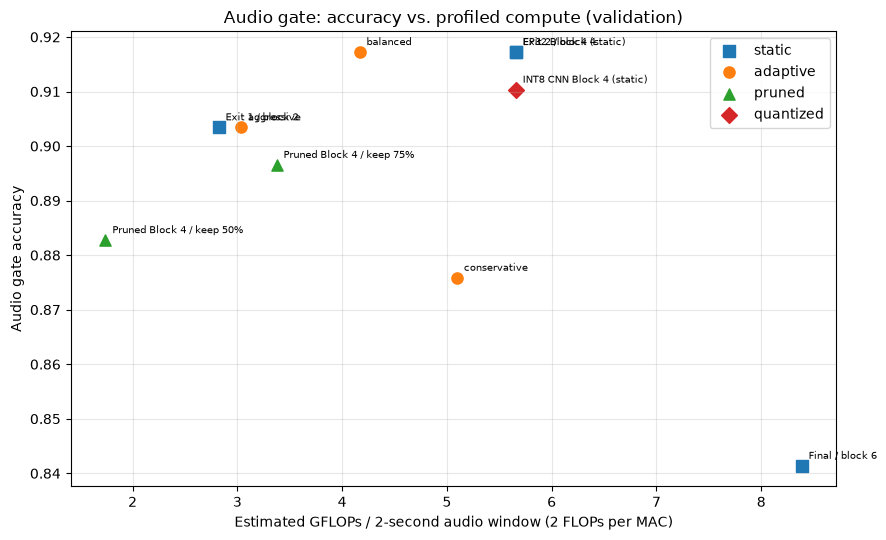

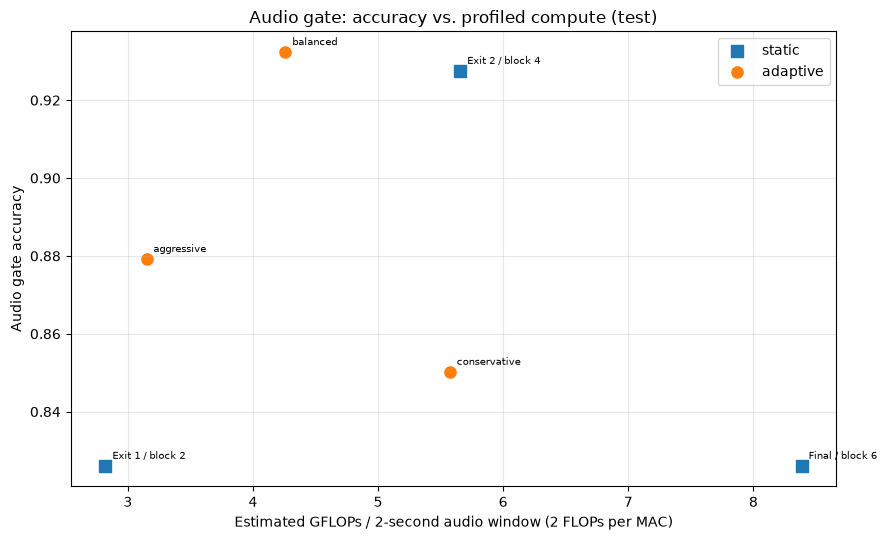

Nondominated validation candidates (FLOPs vs accuracy; min recall 95%):


,model,type,gflops_est,accuracy,animal_recall,background_rejection
0,Pruned Block 4 / keep 50%,pruned,1.7410,0.8828,0.9565,0.6000
1,Exit 1 / block 2,static,2.8210,0.9034,0.9565,0.7000
2,balanced,adaptive,4.1662,0.9172,0.9652,0.7333


In [10]:
import matplotlib.pyplot as plt

markers = {"static": "s", "adaptive": "o", "pruned": "^", "quantized": "D"}
for split in ("validation", "test"):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    subset = compare[compare["split"] == split]
    for typ, marker in markers.items():
        part = subset[subset["type"] == typ]
        if part.empty:
            continue
        ax.scatter(part["gflops_est"], part["accuracy"], label=typ,
                   marker=marker, s=65)
        for _, row in part.iterrows():
            name = str(row["model"])
            ax.annotate(name, (row["gflops_est"], row["accuracy"]),
                        xytext=(5, 5), textcoords="offset points", fontsize=7)
    ax.set(title=f"Audio gate: accuracy vs. profiled compute ({split})",
           xlabel="Estimated GFLOPs / 2-second audio window (2 FLOPs per MAC)",
           ylabel="Audio gate accuracy")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

# Validation-only Pareto candidates among feasible >=95% recall operating points.
val_cmp = compare[(compare["split"] == "validation") &
                  (compare["animal_recall"] >= 0.95)].copy()
val_cmp = val_cmp.sort_values(["gflops_est", "accuracy"], ascending=[True, False])
frontier=[]
best_accuracy=-float("inf")
for _, row in val_cmp.iterrows():
    if float(row["accuracy"]) > best_accuracy + 1e-12:
        frontier.append(row.to_dict())
        best_accuracy = float(row["accuracy"])
print("Nondominated validation candidates (FLOPs vs accuracy; min recall 95%):")
display(pd.DataFrame(frontier)[["model", "type", "gflops_est", "accuracy", "animal_recall", "background_rejection"]].round(4))

In [13]:
import time

# The quantized TorchScript export was calibrated on training data in the compression notebook.
q_path = Path(registry["int8"]["trunk_torchscript_path"])
quantized_cpu_cnn = torch.jit.load(str(q_path), map_location="cpu").eval()
float_cpu_cnn = deepcopy(PrunedFourBlockTrunk(backbone, [64, 128, 256, 512])).cpu().eval()
for i in range(1, 5):
    original_block = getattr(
        backbone, f"conv_block{i}"
    )

    clean_state_dict = {
        k: v.detach().cpu()
        for k, v in original_block.state_dict().items()
        if k.split(".")[-1] not in (
            "total_ops",
            "total_params",
        )
    }

    float_cpu_cnn.blocks[i - 1].load_state_dict(
        clean_state_dict,
        strict=True,
    )

print("FP32 CPU CNN weights loaded successfully")
float_cpu_head = deepcopy(head2).cpu().eval()


with torch.inference_mode():
    d = dummy.to(DEVICE)
    mel = backbone.logmel_extractor(backbone.spectrogram_extractor(d))
    mel = mel.transpose(1,3)
    mel = backbone.bn0(mel)
    mel_cpu = mel.transpose(1,3).cpu()

float_cpu_cnn.eval()
quantized_cpu_cnn.eval()

with torch.inference_mode():
    int8_output = quantized_cpu_cnn(mel_cpu)
    fp32_output = float_cpu_cnn(mel_cpu)

assert int8_output.shape == fp32_output.shape == (1, 512)

print("FP32 and INT8 inference successful")

def bench_cpu(module, head, input_tensor, warmups=5, runs=20):
    import time

    module.eval()
    head.eval()

    durations = []

    with torch.inference_mode():
        # Warmup
        for _ in range(warmups):
            features = module(input_tensor)
            _ = head(features)

        # Benchmark
        for _ in range(runs):
            start = time.perf_counter()

            features = module(input_tensor)
            _ = head(features)

            elapsed = time.perf_counter() - start
            durations.append(elapsed * 1000)

    return float(np.median(durations))

fp32_cpu_ms = bench_cpu(float_cpu_cnn, float_cpu_head, mel_cpu)
int8_cpu_ms = bench_cpu(quantized_cpu_cnn, float_cpu_head, mel_cpu)
latencies = pd.DataFrame([
    {"model":"FP32 Block 4 CNN+head", "median_cpu_ms":fp32_cpu_ms},
    {"model":"INT8 Block 4 CNN+FP32 head", "median_cpu_ms":int8_cpu_ms},
])
display(latencies.round(3))
latencies.to_csv(RESULTS_DIR / "panns_audio_cpu_int8_latency_2p0s.csv", index=False)
print("Ratio FP32/INT8:", round(fp32_cpu_ms / int8_cpu_ms, 3), "x (CNN+head CPU only)")

FP32 CPU CNN weights loaded successfully
FP32 and INT8 inference successful


,model,median_cpu_ms
0,FP32 Block 4 CNN+head,26.382
1,INT8 Block 4 CNN+FP32 head,52.765


Ratio FP32/INT8: 0.5 x (CNN+head CPU only)


In [14]:
# Simple break-even analysis for the currently selected audio policies.
# These are the minimum fixed visual costs (GFLOPs/video inference)
# required before adding audio is cheaper than always running vision.
# The actual condition will depend on the vision pipeline's early exits.

break_even = policies[["split", "operating_point", "expected_audio_gflops", "vision_skip_rate"]].copy()
break_even["min_vision_gflops_to_break_even"] = np.where(
    break_even["vision_skip_rate"] > 0,
    break_even["expected_audio_gflops"] / break_even["vision_skip_rate"],
    np.inf,
)
display(break_even.round(4))
break_even.to_csv(RESULTS_DIR / "panns_audio_vision_break_even_2p0s.csv", index=False)

,split,operating_point,expected_audio_gflops,vision_skip_rate,min_vision_gflops_to_break_even
0,validation,aggressive,3.0354,0.1793,16.9285
1,validation,balanced,4.1662,0.1793,23.2347
2,validation,conservative,5.0957,0.1517,33.5853
3,test,aggressive,3.1493,0.3043,10.3479
4,test,balanced,4.2592,0.3575,11.9142
5,test,conservative,5.5735,0.3140,17.7494
